<div class='heading'>
    <div style='float:left;'><h1>CPSC 8810: Machine Learning for Graphs</h1></div>
     <img style="float: right; padding-right: 10px" width="100" src="https://raw.githubusercontent.com/bsethwalker/clemson-cs4300/main/images/clemson_paw.png"> </div>
     </div>

**Clemson University**<br>
**Instructor(s):** Aaron Masino <br>

## Lab 6: Knowledge Graph Completion & Reasoning
This notebook illustrates implementation of the TransE method for knowledge graph completion and its application to predictive path queries in knowledge graphs. 

### Learning Objectives
1. Understand the _triples_ data structure
2. Implement the TransE knowledge graph completion method
3. Create a method to execute predictive path queries using TransE 
4. Evaluate the results of TransE predictive path queries

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

import torch

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

# set device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
    
print(f"Using device: {device}")

RANDOM_SEED = 654321

---
# Part 1: Understanding Triples 

Before implementing and applying the TransE method, let's first gain an understanding of the data structure used to represent our knowledge graph.

We will be using data representing knowledge graphs (KGs) stored in _triples_ format as discussed below. For this lab, we'll assume the KG information is stored in three files:
-    `{dataset_name}_triples_{split}.pt` : a pytorch tensor file containing the triples for the KG `dataset_name` in the `split` (train, val, test)
-    `{dataset_name}_entity_map.tsv` : a tsv file containing the index to string mapping between entity integer ids used in the triples data and a string name
-    `{dataset_name}_relation_map.tsv` : a tsv file containing the index to string mapping between relation type integer ids used in the triples data and a string name

The helper functions below load the triples data into a PyTorch tensor and the mapping data into Python dictionaires.

In [ ]:
def triples_file_name(directory, dataset_name, split):
    return os.path.join(directory, f"{dataset_name}_triples_{split}.pt")

def load_triples_tensor(directory, dataset_name, split):
    return torch.load(triples_file_name(directory, dataset_name, split))

def load_kg_idx_to_name_map(directory, dataset_name, entity_or_relation):
    path = os.path.join(directory, f"{dataset_name}_{entity_or_relation}_map.tsv")
    return pd.read_csv(path, sep="\t", header=None, names=["id", "name"]).set_index("id")["name"].to_dict()

Knowledge graph data is often stored in __triples__ format _(h, r, t)_ where _h_ represent the head entity, _r_ represents the relation type, and _t_ is the tail entity. For example, the triple _(Einstein, profession, physicist)_ indicates the realtion _Einstein's profession is physicist_. 

Here we consider a simple _Countries_ knowledge graph where the entities are all geographical locations (countries, continents, etc) and the relation types are _located in_ and _neighbor_. Thus, the triples are of the form (Clemson, locatedin, South Carolina) and (South Carolina, neighbor, North Carolina), though these relations are not in the _Countries_ KG. If you are interested there are many more KGs available publically, e.g., see the datasets in the Python [PyKeen](https://github.com/pykeen) libary. 

Let's start by loading the _Countries_ triple data and looking at some of the triples in the training dataset.

In [ ]:
countries_train = load_triples_tensor("../data/countries", "countries", "train")
countries_val = load_triples_tensor("../data/countries", "countries", "val")
countries_test = load_triples_tensor("../data/countries", "countries", "test")

Let's take a look at a few samples of the triples data.

In [ ]:
countries_train[0:5]

Each entry in the tensor above is a triple indicating a relation between two locations. We can make these "human" readable by using the index to name mappings provided in the knowledge graph data to convert the integer IDs of the entities and relations to their string representation. 

Let's load these integer to string mappings and examine their content:

In [ ]:
countries_relation_idx_to_name_map = load_kg_idx_to_name_map("../data/countries", "countries", "relation")
for k, v in countries_relation_idx_to_name_map.items():
    print(f"{k}: {v}")

In [ ]:
countries_entity_idx_to_name_map = load_kg_idx_to_name_map("../data/countries", "countries", "entity")
for k, v in countries_entity_idx_to_name_map.items():
    print(f"{k}: {v}")
    if k > 4:
        break

Now let's use these to print some of the triples in human readable form:

In [ ]:
for i in range(5):
    h, r, t = countries_train[i].tolist()
    print(f"({countries_entity_idx_to_name_map[h]}, {countries_relation_idx_to_name_map[r]}, {countries_entity_idx_to_name_map[t]})")

Later in this lab, it will also be useful to have a map from the entity string name to its integer id, so let's create that now.

In [ ]:
countries_entity_name_to_idx_map = {v: k for k, v in countries_entity_idx_to_name_map.items()}
countries_entity_name_to_idx_map['albania']

---
# Part 2: TransE Model

We will know implement the TransE method from scratch using the PyTorch library. Considering the figure below, we will decompose the TransE approach by developing separate Python methods to do the following:

1. Initialize relation and entity embeddings
2. Create a batch iterator that yields sample triples for minibatch training
3. Form courrupt (negative) samples for training
4. Compute the TransE distance function 
5. Compute the TransE loss function 
6. Execute TransE training

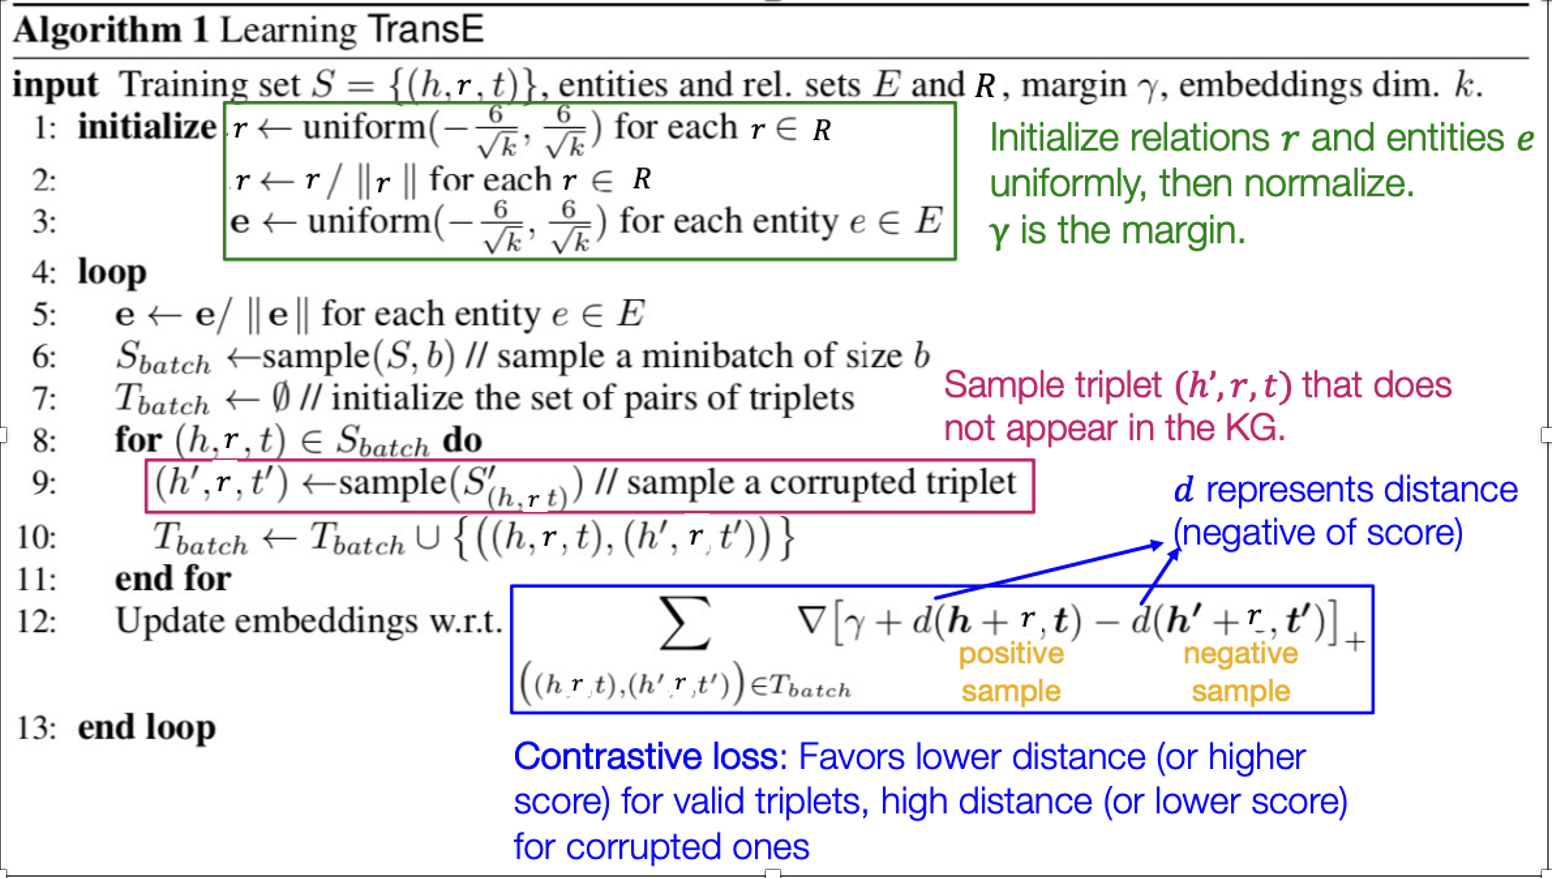

### 2.1 Entity and relation embedding initialization

This method will create the PyTorch tensors for the enitity and relation embeddings following the specifications of the TransE approach. It takes as input:
- `num_entities` : the number of entities in the knowledge graph
- `num_relations` : the number of relations in the knowledge graph
- `embedding_dim` : the size of the embedding dimension

The method should return two PyTorch tensors, one for the entity embeddings and one for the relation embeddings.

In [ ]:
def initialize_embeddings(num_entities, num_relations, embedding_dim, random_seed=RANDOM_SEED):
    """
    Initialize entity and relation embeddings for TransE.
    
    Args:
        num_entities: number of distinct entities (E)
        num_relations: number of distinct relations (R)
        embedding_dim: dimension of the embedding vectors
    
    Returns:
        entity_embeddings: torch tensor of shape [E, embedding_dim] 
        relation_embeddings: torch tensor of shape [R, embedding_dim]
    """
    E = num_entities      
    R = num_relations      

    # Calculate uniform distribution bounds
    bound = 6.0 / torch.sqrt(torch.tensor(embedding_dim, dtype=torch.float32))
    
    # Initialize entity embeddings
    entity_embeddings = -2 * bound * torch.rand(E, embedding_dim) + bound

    # Initialize relation embeddings
    relation_embeddings = -2 * bound * torch.rand(R, embedding_dim) + bound

    # Normalize embeddings
    entity_embeddings = torch.nn.functional.normalize(entity_embeddings, p=2, dim=1)
    relation_embeddings = torch.nn.functional.normalize(relation_embeddings, p=2, dim=1)
    
    return entity_embeddings, relation_embeddings

In [ ]:
# Test the initialization function
embedding_dim = 32
# set the number of entities as the max key in the entity map + 1
num_entities = max(countries_entity_idx_to_name_map.keys()) + 1
num_relations = max(countries_relation_idx_to_name_map.keys()) + 1
entity_emb, relation_emb = initialize_embeddings(num_entities, num_relations, embedding_dim)

print(f"Entity embeddings shape: {entity_emb.shape}")
print(f"Relation embeddings shape: {relation_emb.shape}")
print(f"Entity embedding norms (should be ~1): {torch.norm(entity_emb, dim=1)[:5]}")
print(f"Relation embedding norms (should be ~1): {torch.norm(relation_emb, dim=1)}")

### 2.2 Batch iterator

During training, we will want a method to iterate over minibatches of the training triples. The `batch_iterator` method below should take as input:
- `triples` : the PyTorch tensor representing all the triples from which we want to draw minibatches
- `batch_size` : the number of triples per batch

The method should return an iterator that yields PyTorch tensors of shape _(batch_size, 3)_. (Why?)

In [ ]:
def batch_iterator(triples, batch_size):
    """
    Create an iterator that yields batches of triples.
    
    Args:
        triples: torch tensor of shape [D, 3] containing (head, relation, tail) triples
        batch_size: size of each batch
    
    Yields:
        batch: torch tensor of shape [batch_size, 3] containing a batch of triples
    """
    num_triples = triples.shape[0]
    
    # Shuffle the indices
    indices = torch.randperm(num_triples)
    
    # Yield batches
    for i in range(0, num_triples, batch_size):
        batch_indices = indices[i:i + batch_size]
        yield triples[batch_indices]

In [ ]:
# Test the batch iterator
batch_size = 10
batches = list(batch_iterator(countries_train, batch_size))

print(f"Number of batches: {len(batches)}")
print(f"First batch shape: {batches[0].shape}")
print(f"Last batch shape: {batches[-1].shape}")
print(f"First batch:\n{batches[0]}")

### 2.3 Negative samples
During model training, we need negative samples (i.e., triples) that are not in the knowledge graph in order to implement the noise contrastive loss. For a given positive sample, _(h, r, t)_, the method below will form a negative sample by corrupting the head, h, or tail, t, by randomly selecting an entity from the KG. It will also check to make sure that the negative sample does not exist in the minibatch - ideally, we should check the entire KG but this could be computationally expensive. The method takes as input:
- `positive_batch` : the tensor representing a batch of triples in the KG
- `num_entities` : the number of entities in the knowledge graph

It returns a new PyTorch tensor of shape _(batch_size, 2, 3)_ such that (i, :, :) is a sample pair (positive and negative) and (i, 0, :) is the positive sample for the pair and (i, 1, :) is the negative sample.

In [ ]:
def create_corrupt_samples(positive_batch, num_entities):
    """
    Create corrupt (negative) samples for a batch of positive triples.
    
    Args:
        positive_batch: torch tensor of shape [b, 3] containing positive triples
        num_entities: total number of entities for corruption
    
    Returns:
        samples: torch tensor of shape [b, 2, 3] where samples[i, 0, :] is positive 
                 and samples[i, 1, :] is the corresponding negative sample
    """
    batch_size = positive_batch.shape[0]
    
    # Create output tensor
    samples = torch.zeros(batch_size, 2, 3, dtype=torch.long)
    
    # Add positive samples
    samples[:, 0, :] = positive_batch
    
    # Create set of existing triples in batch for checking
    batch_set = set()
    for i in range(batch_size):
        h, r, t = positive_batch[i].tolist()
        batch_set.add((h, r, t))
    
    # Generate negative samples
    for i in range(batch_size):
        h, r, t = positive_batch[i].tolist()
        
        # Randomly corrupt either head or tail (50% chance each)
        if torch.rand(1).item() < 0.5:
            # Corrupt head
            while True:
                corrupt_h = torch.randint(0, num_entities, (1,)).item()
                corrupt_triple = (corrupt_h, r, t)
                if corrupt_triple not in batch_set:
                    samples[i, 1, :] = torch.tensor([corrupt_h, r, t])
                    break
        else:
            # Corrupt tail
            while True:
                corrupt_t = torch.randint(0, num_entities, (1,)).item()
                corrupt_triple = (h, r, corrupt_t)
                if corrupt_triple not in batch_set:
                    samples[i, 1, :] = torch.tensor([h, r, corrupt_t])
                    break
    
    return samples

In [ ]:
# Test the corrupt samples function
test_batch = batches[0][:5]  # Use first 5 triples from first batch
samples = create_corrupt_samples(test_batch, num_entities)

print(f"Samples shape: {samples.shape}")
print(f"Original batch shape: {test_batch.shape}")
print("\nPositive and negative pairs:")
for i in range(5):
    pos_h, pos_r, pos_t = samples[i, 0, :].tolist()
    neg_h, neg_r, neg_t = samples[i, 1, :].tolist()
    print(f"Positive: ({pos_h}, {pos_r}, {pos_t})")
    print(f"Negative: ({neg_h}, {neg_r}, {neg_t})")
    print()

### 2.4 TransE distance function

For convenience, let's create a function that computes the L1 norm between two embeddings. The function takes the following inputs:
- `eh` the embedding for the head entity in the triple
- `er` the embedding for the relation in the triple
- `et` the embedding for tail entity in the triple

It returns the L1 norm (distance).

In [ ]:
def dist_transe(eh, er, et):
    """
    Compute TransE distance function: L1 norm of (eh + er - et).
    
    Args:
        eh: head entity embeddings, shape [batch_size, embedding_dim]
        er: relation embeddings, shape [batch_size, embedding_dim]  
        et: tail entity embeddings, shape [batch_size, embedding_dim]
    
    Returns:
        distances: L1 distances, shape [batch_size]
    """
    return torch.norm(eh + er - et, p=1, dim=1)

In [ ]:
# Test the TransE distance function
test_samples = samples[:3]  # Use first 3 positive-negative pairs

# Get embeddings for positive samples
pos_triples = test_samples[:, 0, :]  # shape [3, 3]
pos_h_emb = entity_emb[pos_triples[:, 0]]  # head embeddings
pos_r_emb = relation_emb[pos_triples[:, 1]]  # relation embeddings  
pos_t_emb = entity_emb[pos_triples[:, 2]]  # tail embeddings

# Get embeddings for negative samples
neg_triples = test_samples[:, 1, :]  # shape [3, 3]
neg_h_emb = entity_emb[neg_triples[:, 0]]  # head embeddings
neg_r_emb = relation_emb[neg_triples[:, 1]]  # relation embeddings
neg_t_emb = entity_emb[neg_triples[:, 2]]  # tail embeddings

# Compute distances
pos_distances = dist_transe(pos_h_emb, pos_r_emb, pos_t_emb)
neg_distances = dist_transe(neg_h_emb, neg_r_emb, neg_t_emb)

print(f"Positive distances: {pos_distances}")
print(f"Negative distances: {neg_distances}")
print(f"Distance shapes: {pos_distances.shape}, {neg_distances.shape}")

### 2.5 TransE loss function

We now form the TransE loss function. For a batch of postive and negative samples in triples form, it will get the embedding representation for each element in the triple, compute the distance for the positive pair, compute the distance for the negative pair, and then take the ReLU of the difference of the distances plus the margin (gamma). We use the ReLU because we want to constrain the loss to a minimum of zero so that we don't push the negative sample embeddings "too" far apart, that is no further than the margin. Why?

The method takes as input:
- `batch_samples` : the PyTorch tensor of sample pairs in triples format
- `entity_embeddings` : the PyTorch tensor of entity embeddings
- `relation_embeddings` : the PyTorch tensor of relation embeddings
- `gamma` : the margin

It returns the mean loss over the batch as a PyTorch Tensor. **NOTE**, by using PyTorch tensors for all of the computations in our loss function and returning the final tensor, we ensure that the computation graph includes the embeddings so that if we call the `backward` method on the final tensor, it will include gradients for the embeddings. (Why do we need this?)

In [ ]:
def transe_loss(batch_samples, entity_embeddings, relation_embeddings, gamma=1.0):
    """
    Compute TransE margin-based ranking loss.
    
    Args:
        batch_samples: tensor of shape [b, 2, 3] where batch_samples[i, 0, :] is positive
                      and batch_samples[i, 1, :] is negative triple
        entity_embeddings: tensor of shape [E, d] containing entity embeddings
        relation_embeddings: tensor of shape [R, d] containing relation embeddings
        gamma: margin parameter for the loss
    
    Returns:
        loss: scalar tensor representing the average loss over the batch
    """
    # Extract positive and negative triples
    pos_triples = batch_samples[:, 0, :]  # shape [b, 3]
    neg_triples = batch_samples[:, 1, :]  # shape [b, 3]
    
    # Get embeddings for positive triples
    pos_h_emb = entity_embeddings[pos_triples[:, 0]]    # head embeddings
    pos_r_emb = relation_embeddings[pos_triples[:, 1]]  # relation embeddings
    pos_t_emb = entity_embeddings[pos_triples[:, 2]]    # tail embeddings
    
    # Get embeddings for negative triples
    neg_h_emb = entity_embeddings[neg_triples[:, 0]]    # head embeddings
    neg_r_emb = relation_embeddings[neg_triples[:, 1]]  # relation embeddings
    neg_t_emb = entity_embeddings[neg_triples[:, 2]]    # tail embeddings
    
    # Compute distances
    pos_distances = dist_transe(pos_h_emb, pos_r_emb, pos_t_emb)
    neg_distances = dist_transe(neg_h_emb, neg_r_emb, neg_t_emb)
    
    # Compute margin-based ranking loss: max(0, gamma + d_pos - d_neg)
    loss = torch.relu(gamma + pos_distances - neg_distances)
    
    # Return mean loss over the batch
    return torch.mean(loss)

In [ ]:
# Test the loss function with differentiable embeddings
# Create trainable embeddings (requires_grad=True for backpropagation)
entity_emb_trainable = entity_emb.clone().detach().requires_grad_(True)
relation_emb_trainable = relation_emb.clone().detach().requires_grad_(True)

# Test with our sample batch
test_loss = transe_loss(samples[:5], entity_emb_trainable, relation_emb_trainable, gamma=1.0)

print(f"Loss value: {test_loss.item()}")
print(f"Loss requires grad: {test_loss.requires_grad}")
print(f"Entity embeddings require grad: {entity_emb_trainable.requires_grad}")
print(f"Relation embeddings require grad: {relation_emb_trainable.requires_grad}")

# Test backward pass
test_loss.backward()
print(f"Entity embedding gradients computed: {entity_emb_trainable.grad is not None}")
print(f"Relation embedding gradients computed: {relation_emb_trainable.grad is not None}")

### 2.6 Training and evaluation methods.

Here we implement the `evaluate_transe` and `train_transe` methods. 

The trianing method implements training by iterating over epochs and, within an epoch, over minibatches. For each minibatch, it computes the loss using the current version of the entity and relation embeddings, applies backward on the loss to obtain the gradients of the loss function with respect to the embeddings, and uses an SGD optimizer to update the embeddings. 

The evaluate method calculates the _hits@k_ performance of the TransE method. For the tail completion task where _(h, r)_ is given, and the objective is to predict the correct _t_, the _hits@k_ metric is the number of samples for which the correct _t_ is in the top _k_ ranked predictions.

In [ ]:
def evaluate_transe(val_triples, entity_embeddings, relation_embeddings, num_entities, k_values=[3, 10]):
    """
    Evaluate TransE model on validation set using Hits@K metric.
    
    Args:
        val_triples: validation triples tensor of shape [num_val, 3]
        entity_embeddings: trained entity embeddings
        relation_embeddings: trained relation embeddings
        num_entities: total number of entities
        k_values: list of K values for Hits@K evaluation
    
    Returns:
        metrics: dictionary with Hits@K scores
    """
    
    # Set to eval mode (no gradients needed)
    with torch.no_grad():
        num_val = min(len(val_triples), 1000)  # Limit for computational efficiency
        sample_indices = torch.randperm(len(val_triples))[:num_val]
        val_sample = val_triples[sample_indices]
        
        hits_at_k = {k: 0 for k in k_values}
        
        for i, (h, r, t) in enumerate(val_sample):
            # Get embeddings for this triple
            h_emb = entity_embeddings[h].unsqueeze(0)  # [1, d]
            r_emb = relation_embeddings[r].unsqueeze(0)  # [1, d]
            
            # Compute distances to all possible tail entities
            all_tail_embs = entity_embeddings  # [num_entities, d]
            h_plus_r = h_emb + r_emb  # [1, d]
            
            # Compute distances for all entities as potential tails
            distances = torch.norm(h_plus_r - all_tail_embs, p=1, dim=1)  # [num_entities]
            
            # Get ranking of true tail entity
            _, sorted_indices = torch.sort(distances)
            true_rank = (sorted_indices == t).nonzero(as_tuple=True)[0].item() + 1
            
            # Check hits@k
            for k in k_values:
                if true_rank <= k:
                    hits_at_k[k] += 1
    
    # Convert to percentages
    for k in k_values:
        hits_at_k[k] = hits_at_k[k] / num_val * 100
    
    return hits_at_k

In [ ]:
def train_transe(num_entities, num_relations, train_triples, val_triples, embedding_dim=50, num_epochs=10, 
                 batch_size=128, learning_rate=0.01, gamma=1.0, print_every=10):
    """
    Train TransE model using margin-based ranking loss.
    
    Args:
        train_triples: training triples tensor
        val_triples: validation triples tensor  
        embedding_dim: dimension of embeddings
        num_epochs: number of training epochs
        batch_size: batch size for training
        learning_rate: learning rate for optimizer
        gamma: margin parameter for loss
        print_every: print progress every N epochs
    
    Returns:
        entity_embeddings: trained entity embeddings
        relation_embeddings: trained relation embeddings
        training_losses: list of average losses per epoch
    """
    # Move data to device
    train_triples = train_triples.to(device)
    val_triples = val_triples.to(device)
    
    # Initialize embeddings
    entity_emb, relation_emb = initialize_embeddings(num_entities, num_relations, embedding_dim)
    
    # Move embeddings to device and make trainable
    entity_emb = entity_emb.to(device).requires_grad_(True)
    relation_emb = relation_emb.to(device).requires_grad_(True)
    
    # Set up optimizer
    optimizer = torch.optim.SGD([entity_emb, relation_emb], lr=learning_rate)
    
    # Track training progress
    training_losses = []
    
    print(f"Starting TransE training on {device}...")
    print(f"Entities: {num_entities}, Relations: {num_relations}")
    print(f"Training triples: {len(train_triples)}, Validation triples: {len(val_triples)}")
    print(f"Epochs: {num_epochs}, Batch size: {batch_size}, LR: {learning_rate}, Gamma: {gamma}")
    print("-" * 70)
    
    for epoch in range(num_epochs):
        epoch_losses = []
        
        # Training phase
        # entity_emb.train()
        # relation_emb.train()
        
        for batch in batch_iterator(train_triples, batch_size):
            # Create corrupt samples for this batch
            batch_samples = create_corrupt_samples(batch, num_entities)
            # Move batch to device
            batch_samples = batch_samples.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Compute loss
            loss = transe_loss(batch_samples, entity_emb, relation_emb, gamma)
            
            # Backpropagate
            loss.backward()
            
            # Update embeddings
            optimizer.step()
            
            # Normalize embeddings after update (TransE constraint)
            with torch.no_grad():
                entity_emb.data = torch.nn.functional.normalize(entity_emb.data, p=2, dim=1)
                relation_emb.data = torch.nn.functional.normalize(relation_emb.data, p=2, dim=1)
            
            epoch_losses.append(loss.item())
        
        # Record average epoch loss
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        training_losses.append(avg_loss)
        
        # Validation phase
        if (epoch + 1) % print_every == 0 or epoch == 0:
            val_metrics = evaluate_transe(val_triples, entity_emb, relation_emb, num_entities)
            print(f"Epoch {epoch+1:3d}: Loss = {avg_loss:.4f}, "
                  f"Hits@3 = {val_metrics[3]:.1f}%, Hits@10 = {val_metrics[10]:.1f}%")
    
    print("-" * 70)
    print("Training completed!")
    
    return entity_emb, relation_emb, training_losses

Let's train our TransE embeddings.

In [ ]:
# Train the TransE model on Countries dataset
embedding_dim = 64
# set the number of entities as the max key in the entity map + 1
num_entities = max(countries_entity_idx_to_name_map.keys()) + 1
num_relations = max(countries_relation_idx_to_name_map.keys()) + 1
torch.manual_seed(RANDOM_SEED)
trained_entity_emb, trained_relation_emb, losses = train_transe(
    num_entities, num_relations, countries_train, countries_val, 
    embedding_dim=embedding_dim, 
    num_epochs=250, 
    batch_size=64, 
    learning_rate=0.01,
    gamma=1.0,
    print_every=10
)

Let's evaluate the performance on the test set.

In [ ]:
# Plot training progress
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
# Final evaluation on test set
test_metrics = evaluate_transe(countries_test, trained_entity_emb, trained_relation_emb, 
                              trained_entity_emb.shape[0], k_values=[3, 5])
print(f"\nFinal Test Results:")
print(f"Hits@3: {test_metrics[3]:.1f}%")
print(f"Hits@5: {test_metrics[5]:.1f}%")

plt.bar(['Hits@3', 'Hits@5'], [test_metrics[3], test_metrics[5]])
plt.title('Test Set Performance')
plt.ylabel('Accuracy (%)')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

---
# Part 3: Predictive Path Queries with TransE

Now that we've trained our knowledge graph embeddings to support the knowledge graph completion task using the TransE method, let's see how we can apply these embeddings to support predictive path queries. 

First, let's gather all of the triples into a single Tensor representing the existing knowledge graph so we can easily examine expected answers to queries. Let's also create a method to print the relations for a given entity in human readable form.

In [ ]:
def collect_all_triples(train_triples, val_triples, test_triples):
    """
    Combine train, validation, and test triples into a single tensor.
    
    Args:
        train_triples: training triples tensor
        val_triples: validation triples tensor
        test_triples: test triples tensor
    """
    return torch.cat([train_triples, val_triples, test_triples], dim=0)

Let's create a method that prints all triples involving a particular entity in human readable form.

In [ ]:
def print_triples_for_entity(entity_id, all_triples, entity_idx_to_name_map, relation_idx_to_name_map):
    """
    Print all triples involving a particular entity in human readable form.
    
    Args:
        entity_id: ID of the entity to look up
        all_triples: tensor of shape [D, 3] containing all triples
        entity_idx_to_name_map: dictionary mapping entity IDs to names
        relation_idx_to_name_map: dictionary mapping relation IDs to names
    """
    entity_name = entity_idx_to_name_map.get(entity_id, f"Unknown({entity_id})")
    print(f"Triples involving entity '{entity_name}':")
    for h, r, t in all_triples:
        if h.item() == entity_id or t.item() == entity_id:
            h_name = entity_idx_to_name_map.get(h.item(), f"Unknown({h.item()})")
            r_name = relation_idx_to_name_map.get(r.item(), f"Unknown({r.item()})")
            t_name = entity_idx_to_name_map.get(t.item(), f"Unknown({t.item()})")
            print(f"({h_name}, {r_name}, {t_name})")

Let's test this for Bulgaria.

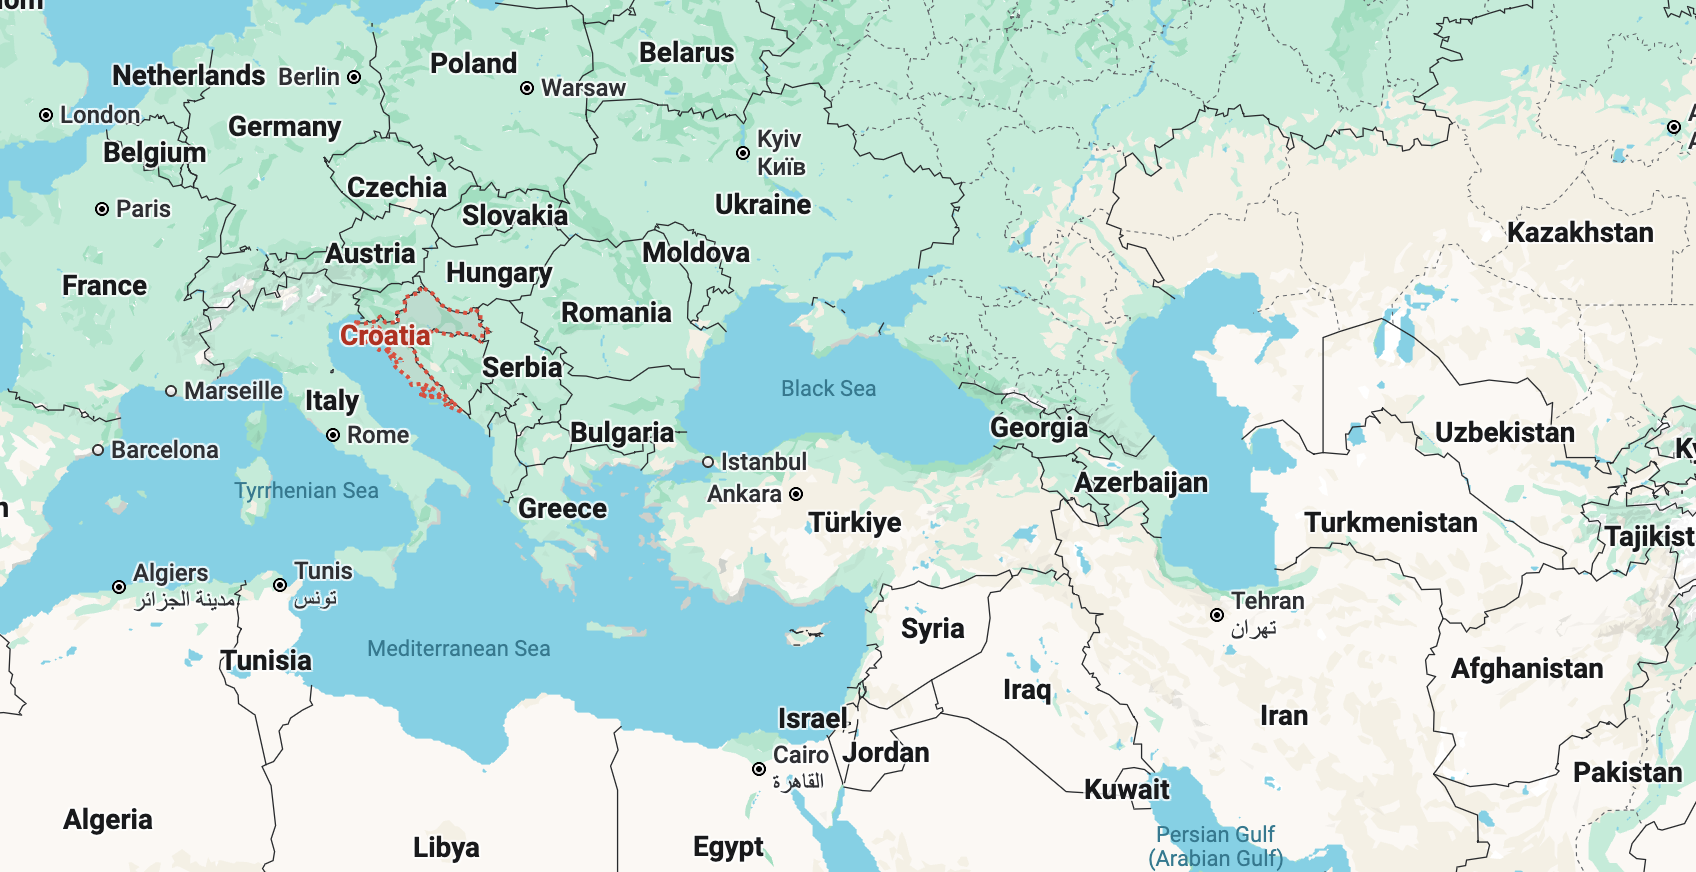

In [ ]:
# find the triples involving bulgaria
bulgaria_id = countries_entity_name_to_idx_map['bulgaria']
bulgaria_triples = []
countries_all_triples = collect_all_triples(countries_train, countries_val, countries_test)
print_triples_for_entity(bulgaria_id, countries_all_triples, countries_entity_idx_to_name_map, countries_relation_idx_to_name_map)

Now let's develop the `predictive_path_query` method. It takes queries in the form (e, R) where e is the anchor entity and R is a list of relation types. For example, the query, which countries are neighbors of the United States would have e=index(United States) (i.e., the index in the embedding tensor) and R = [index(neighbor)]. The function also takes the entity and relation embeddings and k, the number of hits to return. The approach first sums the anchor entity embedding with each of the relation embeddings in the query to obtain the final query embedding. The distance between the query embedding and all entity embeddings is used to the entities that are closest to the query embedding. 

In [ ]:
def predictive_path_query(anchor_entity, relation_path, entity_embeddings, 
                          relation_embeddings, k=10):
    """
    Perform predictive path query using TransE embeddings.
    
    Args:
        anchor_entity: integer ID of the starting entity
        relation_path: list of relation integer IDs representing the path
        entity_embeddings: trained entity embeddings tensor [E, d]
        relation_embeddings: trained relation embeddings tensor [R, d]
        k: number of top hits to return
    
    Returns:
        top_entities: tensor of top k entity IDs
        top_distances: tensor of corresponding distances
    """
    with torch.no_grad():
        # Get anchor entity embedding
        query_embedding = entity_embeddings[anchor_entity].clone()  # [d]
        
        # Add each relation embedding in the path
        for relation_id in relation_path:
            query_embedding += relation_embeddings[relation_id]
        
        # Compute distances to all entities
        # query_embedding: [d], entity_embeddings: [E, d]
        # We want ||query_embedding - entity_embeddings[i]||_1 for all i
        distances = torch.norm(query_embedding.unsqueeze(0) - entity_embeddings, p=1, dim=1)  # [E]
        
        # Get top k entities with smallest distances
        top_distances, top_indices = torch.topk(distances, k, largest=False)
        
        return top_indices, top_distances

Let's try the predictive query for a couple of examples. First, let's consider a single hop query, "What countries neighbor Bulgaria?". This query is answered by the query:

 __Bulgaria->neighbors->?__ 

In [ ]:
# Example predictive path queries

# Query 1: Single hop - "What countries are neighbors of Bulgaria?"
anchor_id = countries_entity_name_to_idx_map['bulgaria']  # We know this from earlier exploration
neighbor_relation = 1  # neighbor relation

top_entities, distances = predictive_path_query(anchor_id, [neighbor_relation], 
    trained_entity_emb, trained_relation_emb, k=5
)

print("Query: What are Bulgaria's neighbors?")
print("Top 5 predictions:")
for i, (entity_id, distance) in enumerate(zip(top_entities, distances)):
    entity_name = countries_entity_idx_to_name_map[entity_id.item()]
    print(f"{i+1}. {entity_name} (distance: {distance:.3f})")

Now, let's try a multihop query, "Where are the neighbors of Bulgaria located?". This query is answered by the query:

**Bulgaria->neighbors->locatedin->?**

In [ ]:
# Example predictive path queries

# Query 2: Multiple hops - "Where are the neighbors of Bulgaria located?"
anchor_id = countries_entity_name_to_idx_map['bulgaria']  # We know this from earlier exploration
neighbor_relation = 1  # neighbor relation
locatedin_relation = 0

top_entities, distances = predictive_path_query(
    anchor_id, [neighbor_relation, locatedin_relation], 
    trained_entity_emb, trained_relation_emb, k=5
)

print("Query: Where are the neighbors of Bulgaria located?")
print("Top 5 predictions:")
for i, (entity_id, distance) in enumerate(zip(top_entities, distances)):
    entity_name = countries_entity_idx_to_name_map[entity_id.item()]
    print(f"{i+1}. {entity_name} (distance: {distance:.3f})")